#Build Simple Workflow or Graph using LangGraph

In [68]:
from typing_extensions import TypedDict

class State(TypedDict):
    graph_info:str

In [69]:

def start_play(State:State):
   print("Start_play node has been called")
   return {"graph_info":State['graph_info'] + " I am planning to Play "}

def Cricket(State:State):
   print("Cricket node has been called")
   return {"graph_info":State['graph_info'] + "Cricket"}

def FootBall(State:State):
    print("FootBall node has been called")
    return {"graph_info":State['graph_info'] + "FootBall"}

In [70]:
import random
from typing import Literal

def random_play(State: State) -> Literal["Cricket", "FootBall"]:
    graph_info = State["graph_info"]

    if random.random() > 0.5:
        return "Cricket"
    else:
        return "FootBall"

In [71]:
from IPython.display import Image, display
from langgraph.graph import StateGraph,START,END

#Build the Graph
graph=StateGraph(State)

#Adding the Nodes to the Graph
graph.add_node("start_play", start_play)
graph.add_node("Cricket", Cricket)
graph.add_node("FootBall", FootBall)

In [72]:
#Schedule the graph
graph.add_edge(START,"start_play")
graph.add_conditional_edges("start_play",random_play)
graph.add_edge("Cricket",END)
graph.add_edge("FootBall",END)

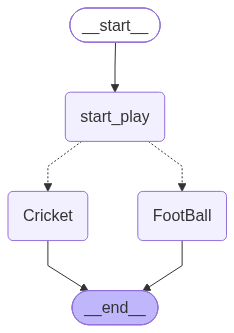

In [73]:
#Compile The Graph
graph_builder=graph.compile()

#View the Designed Graph
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [74]:
##Invoking the Graph
graph_builder.invoke({"graph_info":"Hello, I am onkar and"})

Start_play node has been called
Cricket node has been called


{'graph_info': 'Hello, I am onkar and I am planning to Play Cricket'}